- Đọc data
- Xử lý clean data
- Chia train, test
- Scale data
- Train

In [31]:
import pandas as pd

file_path = '/content/drive/MyDrive/DATN/fetal_health.csv'
data = pd.read_csv(file_path)
display(data.head())

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


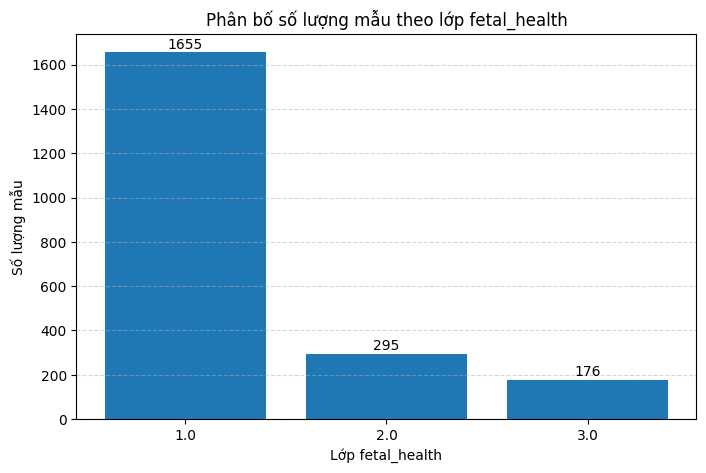

In [32]:
import matplotlib.pyplot as plt

# Đếm số lượng mẫu của từng lớp
class_counts = data['fetal_health'].value_counts().sort_index()

# Vẽ biểu đồ cột
plt.figure(figsize=(8,5))
bars = plt.bar(class_counts.index.astype(str), class_counts.values)

# Hiển thị số trên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval),
             ha='center', va='bottom', fontsize=10)

plt.title('Phân bố số lượng mẫu theo lớp fetal_health')
plt.xlabel('Lớp fetal_health')
plt.ylabel('Số lượng mẫu')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

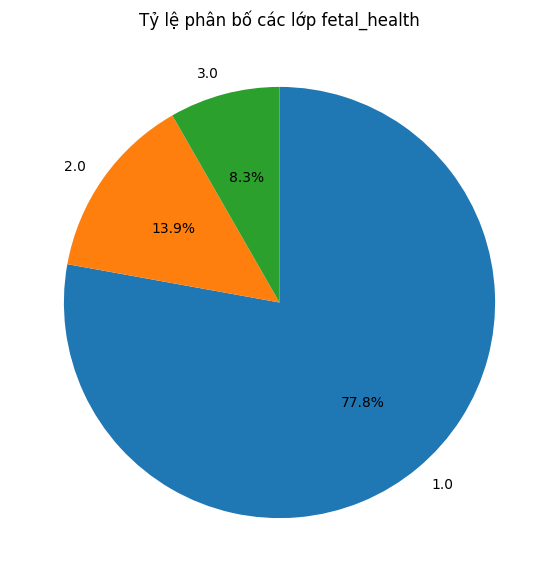

In [33]:
import matplotlib.pyplot as plt

# Đếm số lượng mẫu của từng lớp
class_counts = data['fetal_health'].value_counts().sort_index()

# Nhãn cho từng lớp
labels = class_counts.index.astype(str)

# Vẽ biểu đồ tròn
plt.figure(figsize=(7, 7))
plt.pie(
    class_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)

plt.title('Tỷ lệ phân bố các lớp fetal_health')
plt.show()

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [35]:
data.shape

(2126, 22)

In [36]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


In [37]:
negative_values_found = False
for column in data.select_dtypes(include=['number']).columns:
    negative_count = (data[column] < 0).sum()
    if negative_count > 0:
        print(f"Cột '{column}' có {negative_count} giá trị nhỏ hơn 0.")
        negative_values_found = True

if not negative_values_found:
    print("Không tìm thấy giá trị nào nhỏ hơn 0 trong các cột số.")

Cột 'histogram_tendency' có 165 giá trị nhỏ hơn 0.


In [38]:
data["histogram_tendency"].value_counts()

,count
histogram_tendency,
0.0,1115
1.0,846
-1.0,165


In [39]:
data["fetal_health"].value_counts()

,count
fetal_health,
1.0,1655
2.0,295
3.0,176


In [40]:
from sklearn.model_selection import train_test_split
X = data.drop('fetal_health', axis=1)
y = data['fetal_health']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Kích thước tập huấn luyện X: {X_train.shape}")
print(f"Kích thước tập kiểm tra X: {X_test.shape}")
print(f"Kích thước tập huấn luyện y: {y_train.shape}")
print(f"Kích thước tập kiểm tra y: {y_test.shape}")

Kích thước tập huấn luyện X: (1700, 21)
Kích thước tập kiểm tra X: (426, 21)
Kích thước tập huấn luyện y: (1700,)
Kích thước tập kiểm tra y: (426,)


In [41]:
# from sklearn.preprocessing import StandardScaler

# # Khởi tạo scaler
# scaler = StandardScaler()

# # Fit trên tập train, transform cả train và test
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Nếu muốn giữ dạng DataFrame để dễ nhìn tên cột
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# print("Đã scale dữ liệu xong")
# display(X_train_scaled.head())

In [42]:
from sklearn.preprocessing import MinMaxScaler

# Khởi tạo scaler
scaler = MinMaxScaler()

# Fit trên train, transform cả train và test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Nếu muốn giữ DataFrame
import pandas as pd
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
print("Đã scale dữ liệu xong")
display(X_train_scaled.head())

Đã scale dữ liệu xong


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
1953,0.500000,0.000000,0.000000,0.857143,0.066667,0.0,0.4,0.648649,0.411765,0.000000,...,0.543353,0.073394,0.284483,0.222222,0.0,0.511811,0.211009,0.256881,0.311024,0.5
1439,0.740741,0.333333,0.000000,0.214286,0.000000,0.0,0.0,0.351351,0.117647,0.000000,...,0.265896,0.697248,0.456897,0.166667,0.0,0.708661,0.724771,0.697248,0.019685,0.5
2033,0.425926,0.000000,0.002096,0.500000,0.400000,0.0,0.4,0.743243,0.441176,0.000000,...,0.445087,0.146789,0.206897,0.388889,0.0,0.354331,0.064220,0.275229,0.035433,0.5
1731,0.518519,0.444444,0.002096,0.714286,0.400000,0.0,0.0,0.662162,0.132353,0.000000,...,0.612717,0.275229,0.577586,0.555556,0.0,0.755906,0.651376,0.678899,0.240157,0.5
241,0.351852,0.000000,0.010482,0.071429,0.066667,0.0,0.0,0.783784,0.029412,0.318681,...,0.450867,0.018349,0.094828,0.277778,0.0,0.511811,0.458716,0.440367,0.007874,1.0


Random forest

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Khởi tạo model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train model với dữ liệu đã scale
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred = rf_model.predict(X_test_scaled)

# Đánh giá
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision weighted:", precision_score(y_test, y_pred, average='weighted'))
print("Recall weighted:", recall_score(y_test, y_pred, average='weighted'))
print("F1 weighted:", f1_score(y_test, y_pred, average='weighted'))

print("Precision macro:", precision_score(y_test, y_pred, average='macro'))
print("Recall macro:", recall_score(y_test, y_pred, average='macro'))
print("F1 macro:", f1_score(y_test, y_pred, average='macro'))
print("\nDetail about one class:")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9272300469483568
Precision weighted: 0.9242815167649892
Recall weighted: 0.9272300469483568
F1 weighted: 0.924450359709892
Precision macro: 0.8793326854551345
Recall macro: 0.8380082071627916
F1 macro: 0.8559231238358964

Detail about one class:
Classification Report:
               precision    recall  f1-score   support

         1.0       0.95      0.98      0.96       332
         2.0       0.83      0.68      0.75        59
         3.0       0.86      0.86      0.86        35

    accuracy                           0.93       426
   macro avg       0.88      0.84      0.86       426
weighted avg       0.92      0.93      0.92       426


Confusion Matrix:
 [[325   5   2]
 [ 16  40   3]
 [  2   3  30]]


XGBoot

In [44]:
y_train = y_train.astype(int) - 1
y_test = y_test.astype(int) - 1

In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Khởi tạo model XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',   # dùng cho phân loại nhiều lớp
    num_class=len(y_train.unique()),
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

# Train model
xgb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_xg = xgb_model.predict(X_test_scaled)

# Đánh giá
print("Accuracy:", accuracy_score(y_test, y_pred_xg))
print("Precision weighted:", precision_score(y_test, y_pred_xg, average='weighted'))
print("Recall weighted:", recall_score(y_test, y_pred_xg, average='weighted'))
print("F1 weighted:", f1_score(y_test, y_pred_xg, average='weighted'))

print("Precision macro:", precision_score(y_test, y_pred_xg, average='macro'))
print("Recall macro:", recall_score(y_test, y_pred_xg, average='macro'))
print("F1 macro:", f1_score(y_test, y_pred_xg, average='macro'))

print("\nDetail about one class:")
print("Classification Report:\n", classification_report(y_test, y_pred_xg))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xg))

Accuracy: 0.9413145539906104
Precision weighted: 0.9395383719750976
Recall weighted: 0.9413145539906104
F1 weighted: 0.9393067751860469
Precision macro: 0.9150177029876277
Recall macro: 0.8750089948170405
F1 macro: 0.8926470203423714

Detail about one class:
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97       332
           1       0.88      0.73      0.80        59
           2       0.91      0.91      0.91        35

    accuracy                           0.94       426
   macro avg       0.92      0.88      0.89       426
weighted avg       0.94      0.94      0.94       426


Confusion Matrix:
 [[326   5   1]
 [ 14  43   2]
 [  2   1  32]]
